# Visual Transformer with Pre-trained ViT-B/16

This notebook demonstrates how to fine-tune a pre-trained Vision Transformer (ViT-B/16) from [torchvision.models](https://pytorch.org/vision/main/models/generated/torchvision.models.vit_b_16.html) on the Oxford-IIIT Pets dataset. It includes data loading, splitting, transformations, model preparation, training, validation, testing, and visualization of predictions.


### Цели
- Улучшить бейзлайн не меняя архитектуру
### Улучшения
- Добавлены дополнительные аугментации: RandomPerspective, ColorJitter
- Adam -> AdamW
- Добавлен label smoothing
- Weighted CE
- StepLR -> Cosine Scheduler
- VIT pretrained weights IMAGENET1K_V1 -> IMAGENET1K_SWAG_E2E_V1
### Результаты
- 0.9523 (baseline) -> 0.968
- Результат лучше чем в оригинальной статье VIT
### Прочее
- Добавлена конвертация в ONNX
### Как еще можно было бы улучшить результат?
- Metric learning подход
- SWIN,BIT,CoATNet/ бОльшие версии VIT'a (H,L)
- Distillation
- Ансамбли моделей
- ТТА
- Синтетические данные/ более сложные аугментации
- Обрезка животных с помощью сегментации
- Больше экспериментов с оптимизатором (Lion, hyperparam tuning)/ weights init

## Install and Import Dependencies

In [ ]:
!pip install torchvision
!pip install pytorch_optimizer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.0/68.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.3/231.3 kB 8.6 MB/s eta 0:00:00


In [ ]:
from __future__ import print_function

import glob
import os
import random
import zipfile
import shutil

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from tqdm.notebook import tqdm

## Configuration

In [ ]:
batch_size = 64 #максимальный возможный размер
epochs = 10
lr = 1e-5 #чуть уменьшил
gamma = 0.6
seed = 42

In [ ]:
def seed_everything(seed):
    """
    Sets the random seed for reproducibility in python, numpy, and torch.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(seed)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Data Preparation

In [ ]:
base_dir = '/kaggle/input/the-oxfordiiit-pet-dataset'
images_dir = os.path.join(base_dir, 'images')

In [ ]:
image_paths = glob.glob(os.path.join(images_dir, '*.jpg'))


In [ ]:
def get_breed_from_filename(filename):
    """
    Extract the breed name from the file name.
    Example: Abyssinian_100.jpg -> Abyssinian
    """
    base = os.path.basename(filename)
    name = os.path.splitext(base)[0]
    parts = name.split('_')
    breed = "_".join(parts[:-1])
    return breed

In [ ]:
breeds = [get_breed_from_filename(p) for p in image_paths]
unique_breeds = sorted(list(set(breeds)))
print(f"Nombre total de races : {len(unique_breeds)}")  # should be 37

breed_to_idx = {b:i for i,b in enumerate(unique_breeds)}
labels = [breed_to_idx[b] for b in breeds]

Nombre total de races : 37


In [ ]:
# Split into train, validation, test (70%, 15%, 15%)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.3, stratify=labels, random_state=seed
)

valid_paths, test_paths, valid_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.5, stratify=temp_labels, random_state=seed
)

print(f"Train Data: {len(train_paths)}")
print(f"Validation Data: {len(valid_paths)}")
print(f"Test Data: {len(test_paths)}")

Train Data: 5173
Validation Data: 1108
Test Data: 1109


## Visualize Some Training Images

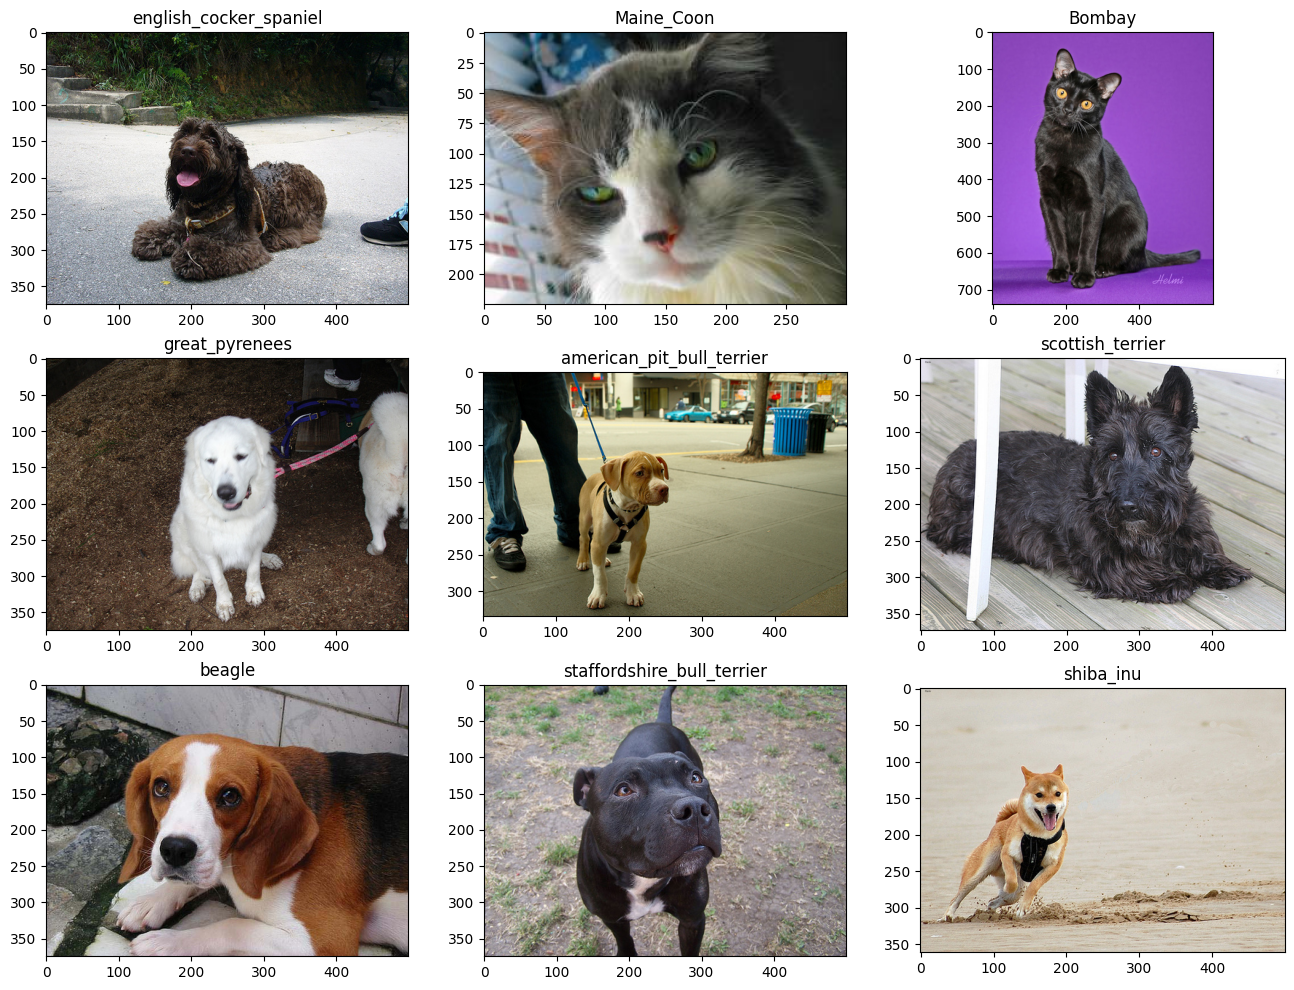

In [ ]:
random_idx = np.random.randint(0, len(train_paths), size=9)
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for idx, ax in zip(random_idx, axes.ravel()):
    img = Image.open(train_paths[idx]).convert("RGB")
    label_idx = train_labels[idx]
    label_name = unique_breeds[label_idx]
    ax.set_title(label_name)
    ax.imshow(img)
plt.show()

### Сложный класc

##### Матрица с предыдущей итерации обучения
![image.png](attachment:eeb4cc55-fac9-4599-9375-b6c253cb5ff0.png)!

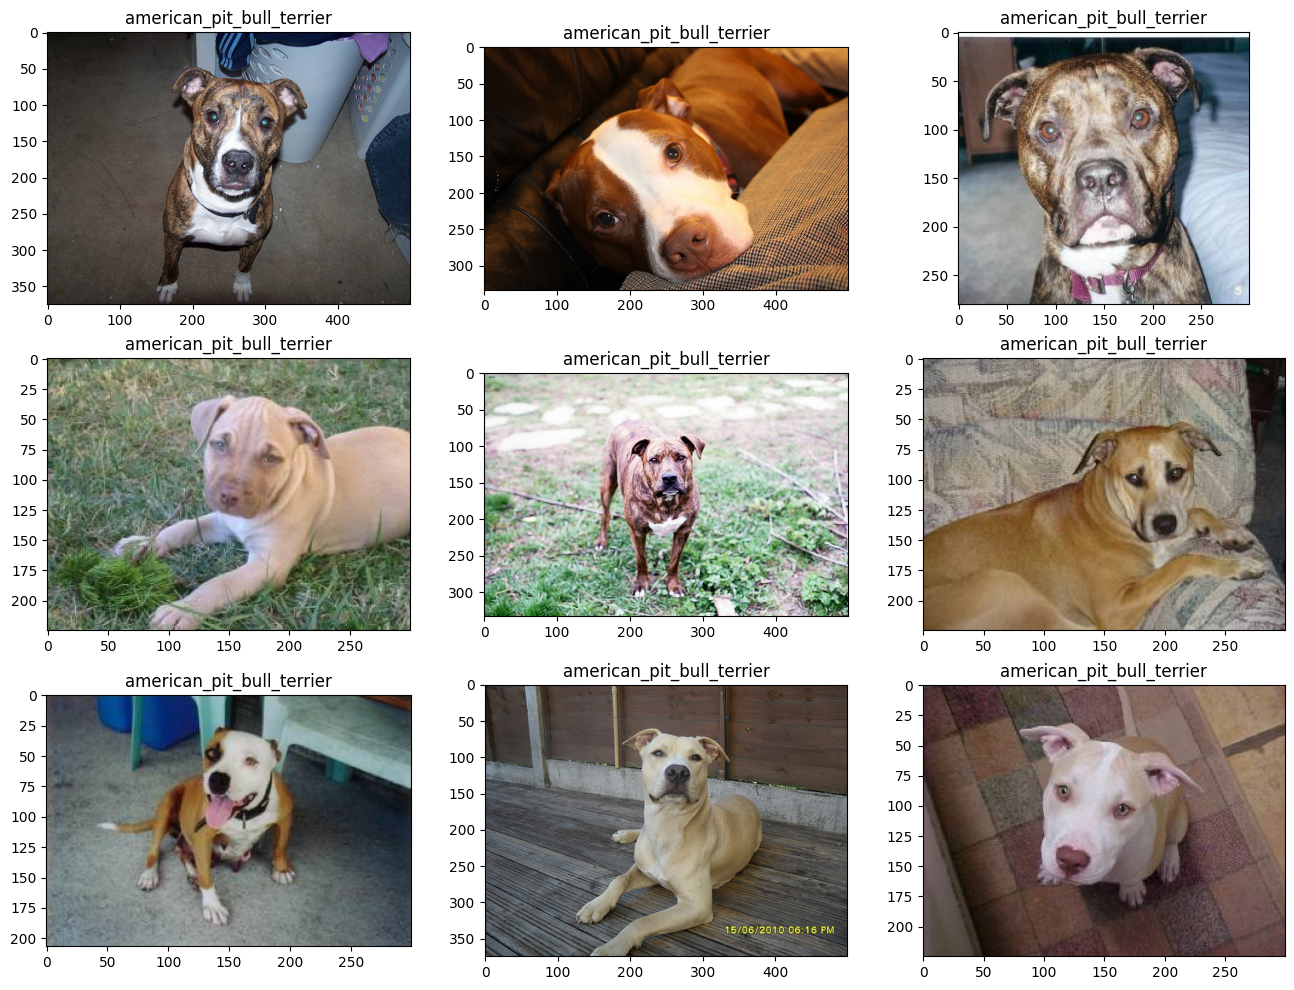

In [ ]:
unique_breeds[13] #класс который классифицируется хуже остальных
random_idx = np.random.choice(np.where(np.array(train_labels)==13)[0], size=9)

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for idx, ax in zip(random_idx, axes.ravel()):
    img = Image.open(train_paths[idx]).convert("RGB")
    label_idx = train_labels[idx]
    label_name = unique_breeds[label_idx]
    ax.set_title(label_name)
    ax.imshow(img)
plt.show()

Image Transformations

We define transformations for training, validation, and test sets.  
Pre-trained ViT-B/16 expects images of size 224x224 and normalization with IMAGENET means/std.


In [ ]:

train_transforms = transforms.Compose([
    transforms.Resize((384, 384)),
    transforms.RandomResizedCrop(384,ratio=[0.6,0.8]),
    transforms.RandomHorizontalFlip(),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.2),
    transforms.ColorJitter(brightness=0.2,contrast=0.1,hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
#добавил ауг на рандомную смену перспективы, ужесточил рандом кроп, добавил ауг по цвету

val_transforms = transforms.Compose([
    transforms.Resize(384),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize(384),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


## Custom Dataset

In [ ]:
class OxfordPetDataset(Dataset):
    def __init__(self, file_list, labels, transform=None):
        self.file_list = file_list
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        img_path = self.file_list[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

## Datasets and DataLoaders

In [ ]:
train_data = OxfordPetDataset(train_paths, train_labels, transform=train_transforms)
valid_data = OxfordPetDataset(valid_paths, valid_labels, transform=val_transforms)
test_data = OxfordPetDataset(test_paths, test_labels, transform=test_transforms)

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=4)
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size, shuffle=False, num_workers=4)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False, num_workers=4)

print(f"Train Dataset size: {len(train_data)}")
print(f"Validation Dataset size: {len(valid_data)}")
print(f"Test Dataset size: {len(test_data)}")

Train Dataset size: 5173
Validation Dataset size: 1108
Test Dataset size: 1109


## Model Preparation

We use a pre-trained ViT-B/16 model from `torchvision.models` and fine-tune the last layer.


In [ ]:
model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_SWAG_E2E_V1) #поменял претрейн веса
model.to(device)

num_classes = len(unique_breeds)
num_ftrs = model.heads.head.in_features
model.heads.head = nn.Linear(num_ftrs, num_classes)

# If multiple GPUs are available
model = nn.DataParallel(model)
model.to(device)

Downloading: "https://download.pytorch.org/models/vit_b_16_swag-9ac1b537.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16_swag-9ac1b537.pth
100%|██████████| 331M/331M [00:01<00:00, 225MB/s]  


DataParallel(
  (module): VisionTransformer(
    (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    (encoder): Encoder(
      (dropout): Dropout(p=0.0, inplace=False)
      (layers): Sequential(
        (encoder_layer_0): EncoderBlock(
          (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (self_attention): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (dropout): Dropout(p=0.0, inplace=False)
          (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): MLPBlock(
            (0): Linear(in_features=768, out_features=3072, bias=True)
            (1): GELU(approximate='none')
            (2): Dropout(p=0.0, inplace=False)
            (3): Linear(in_features=3072, out_features=768, bias=True)
            (4): Dropout(p=0.0, inplace=False)
          )
        )
        (encoder_layer_1): EncoderBlock(
          (ln_1): L

## Training Setup

We'll use CrossEntropyLoss, Adam optimizer, and a StepLR scheduler.

In [ ]:
from pytorch_optimizer import load_optimizer

In [ ]:
w = [1. for i in range(37)]
w[13] = 1.5
w = torch.Tensor(w).cuda()
#докинул вес на сложный класс
criterion = nn.CrossEntropyLoss(weight=w,label_smoothing=0.1) #добавил label smoothing
optimizer = optim.AdamW(model.parameters(), lr=lr) #поменял оптимизатор
#optimizer = load_optimizer(optimizer='lion')(model.parameters(),lr=lr)
scheduler = StepLR(optimizer, step_size=1, gamma=gamma)
#scheduler = CosineAnnealingLR(optimizer, 5,last_epoch=30)

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

## Training Loop

In [ ]:
epochs = 12
#epochs = 30

In [ ]:
for epoch in range(epochs):
    epoch_loss = 0
    epoch_accuracy = 0

    model.train()
    for data, label in tqdm(train_loader, desc=f"Training Epoch {epoch+1}"):
        data = data.to(device)
        label = label.to(device)

        output = model(data)
        loss = criterion(output, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = (output.argmax(dim=1) == label).float().mean()
        epoch_accuracy += acc.item() / len(train_loader)
        epoch_loss += loss.item() / len(train_loader)

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)

    model.eval()
    with torch.no_grad():
        epoch_val_accuracy = 0
        epoch_val_loss = 0
        for data, label in tqdm(valid_loader, desc=f"Validation Epoch {epoch+1}"):
            data = data.to(device)
            label = label.to(device)

            val_output = model(data)
            val_loss = criterion(val_output, label)

            acc = (val_output.argmax(dim=1) == label).float().mean()
            epoch_val_accuracy += acc.item() / len(valid_loader)
            epoch_val_loss += val_loss.item() / len(valid_loader)

    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_accuracy)

    print(
        f"Epoch : {epoch+1} - Loss : {epoch_loss:.4f} - Accuracy: {epoch_accuracy:.4f} - "
        f"Validation loss : {epoch_val_loss:.4f} - Validation Accuracy: {epoch_val_accuracy:.4f}\n"
    )

    scheduler.step()

Training Epoch 1:   0%|          | 0/81 [00:00<?, ?it/s]

/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):


Validation Epoch 1:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch : 1 - Loss : 1.0669 - Accuracy: 0.8753 - Validation loss : 0.8683 - Validation Accuracy: 0.9425



Training Epoch 2:   0%|          | 0/81 [00:00<?, ?it/s]

...

Validation Epoch 11:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch : 11 - Loss : 0.7912 - Accuracy: 0.9633 - Validation loss : 0.7701 - Validation Accuracy: 0.9714



Training Epoch 12:   0%|          | 0/81 [00:00<?, ?it/s]

Validation Epoch 12:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch : 12 - Loss : 0.7715 - Accuracy: 0.9711 - Validation loss : 0.7702 - Validation Accuracy: 0.9722



## Training and Validation Curves

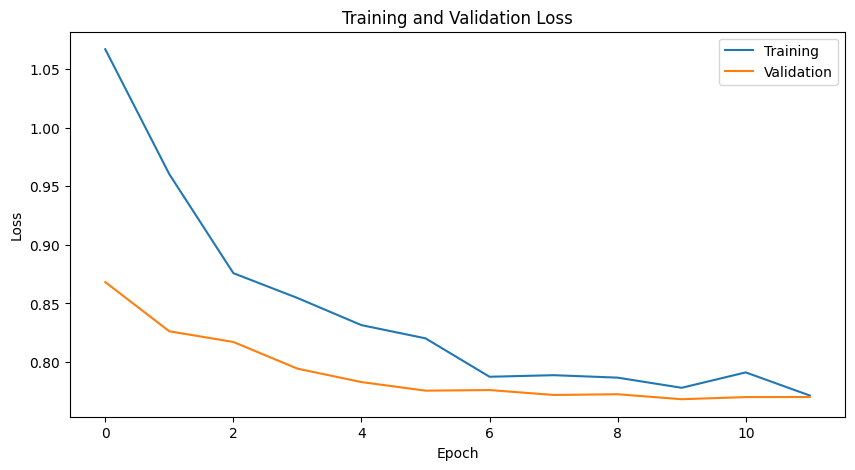

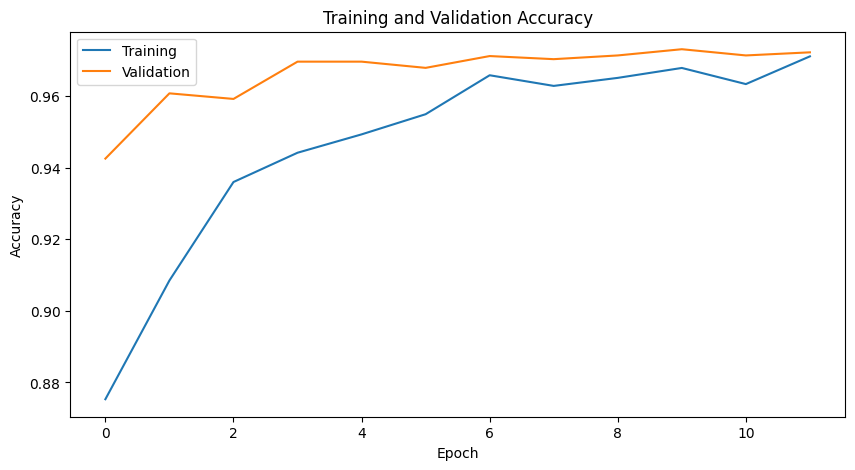

In [ ]:
plt.figure(figsize=(10,5))
plt.title("Training and Validation Loss")
plt.plot(train_losses, label="Training")
plt.plot(val_losses, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.title("Training and Validation Accuracy")
plt.plot(train_accuracies, label="Training")
plt.plot(val_accuracies, label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Testing

In [ ]:
with torch.no_grad():
    test_accuracy = 0
    test_loss = 0
    for data, label in tqdm(test_loader, desc="Testing"):
        data = data.to(device)
        label = label.to(device)

        test_output = model(data)
        loss = criterion(test_output, label)

        acc = (test_output.argmax(dim=1) == label).float().mean()
        test_accuracy += acc.item() / len(test_loader)
        test_loss += loss.item() / len(test_loader)

    print(f"Test Loss: {test_loss:.4f} - Test Accuracy: {test_accuracy:.4f}")


Testing:   0%|          | 0/18 [00:00<?, ?it/s]

Test Loss: 0.7899 - Test Accuracy: 0.9652


### Visualization of Predictions

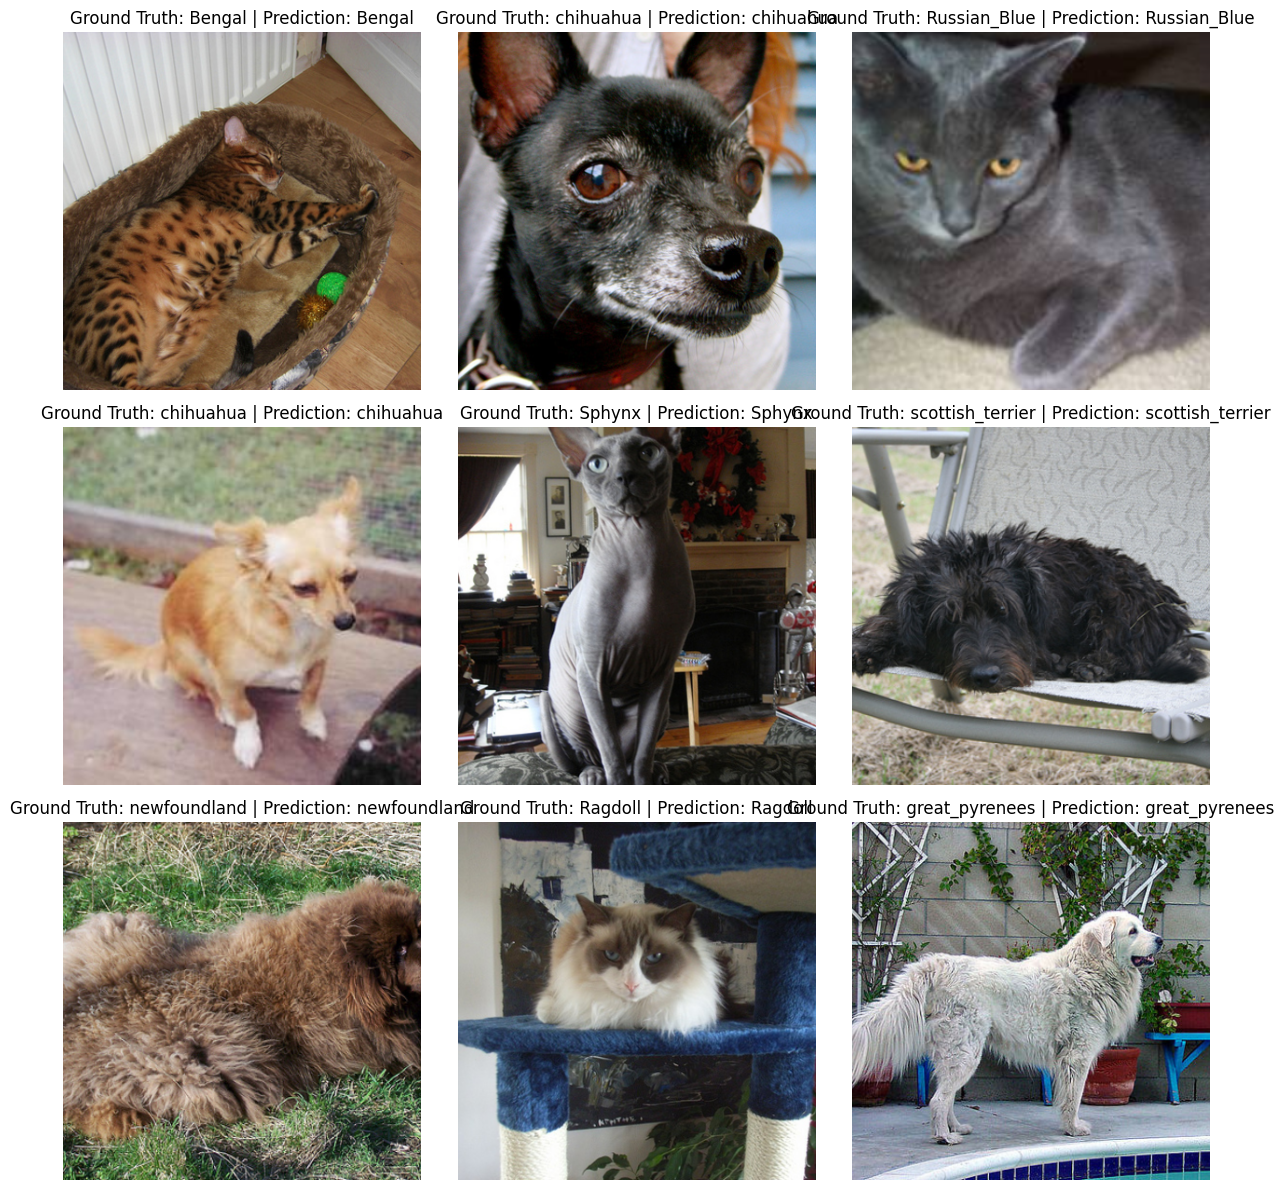

In [ ]:

model.eval()
data_iter = iter(test_loader)
images, labels = next(data_iter)

images = images.to(device)
labels = labels.to(device)

outputs = model(images)
_, preds = torch.max(outputs, 1)

images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, ax in enumerate(axes.ravel()):
        if i >= len(images):
            break
        gt = unique_breeds[labels[i]]
        pred = unique_breeds[preds[i]]
        img = images[i].permute(1, 2, 0)
        # Denormalize for visualization
        img = img * torch.tensor([0.229, 0.224, 0.225]) + torch.tensor([0.485, 0.456, 0.406])
        img = img.numpy()
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.set_title(f"Ground Truth: {gt} | Prediction: {pred}")
        ax.axis("off")
plt.tight_layout()
plt.show()

### Confusion Matrix

Building Confusion Matrix:   0%|          | 0/18 [00:00<?, ?it/s]

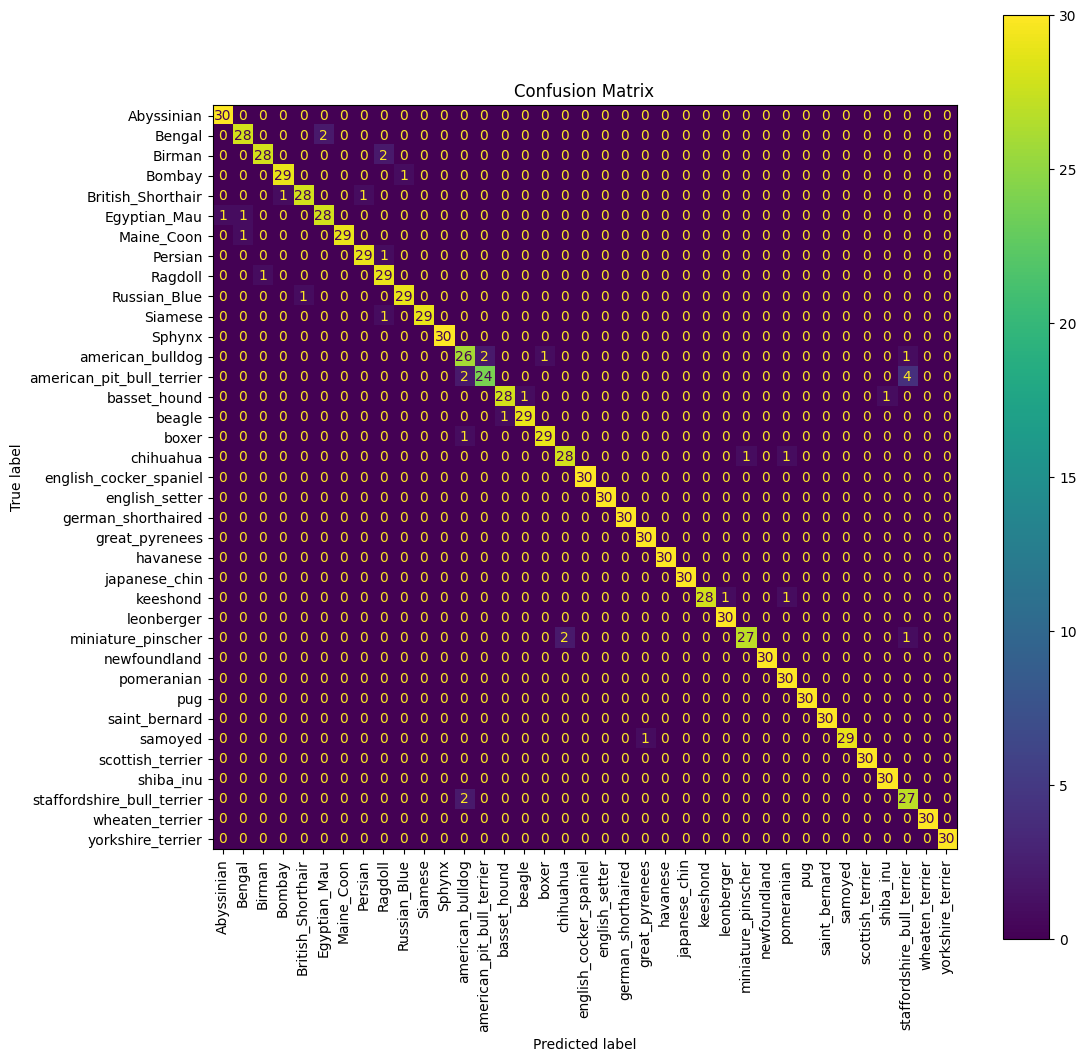

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
true_labels = []
pred_labels = []

with torch.no_grad():
    for data, label in tqdm(test_loader, desc="Building Confusion Matrix"):
        data = data.to(device)
        label = label.to(device)

        outputs = model(data)
        _, pred = torch.max(outputs, 1)

        true_labels.extend(label.cpu().numpy())
        pred_labels.extend(pred.cpu().numpy())

cm = confusion_matrix(true_labels, pred_labels, labels=range(len(unique_breeds)))

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unique_breeds)
disp.plot(ax=ax, cmap="viridis", xticks_rotation=90)
plt.title("Confusion Matrix")
plt.show()


In [ ]:
!pip install onnx
!pip install onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 702.7/702.7 kB 12.3 MB/s eta 0:00:00 0:00:01


In [ ]:
torch.cuda.empty_cache()


In [ ]:
torch_input = torch.randn(8, 3, 384, 384).cuda()
model(torch_input)

tensor([[-1.9784, -0.1143, -1.1853, -0.2243, -0.7384, -0.6047, -0.7886, -0.2533,
          0.7108, -0.1393, -0.8377,  0.1771, -0.5101, -0.1900,  1.2419,  1.5211,
          1.3953,  1.6895,  1.9380, -0.3157,  0.4495,  0.2028, -0.6165, -0.7217,
          0.7895, -1.0708,  0.3860,  0.2323, -0.4005, -1.4827,  0.0512,  1.5117,
         -0.4485,  0.0640, -0.6454, -0.1160, -0.3218],
        [-2.0400,  0.0390, -1.0377, -0.2741, -0.9295, -0.5973, -0.8175, -0.4206,
          0.8667, -0.2469, -0.7494,  0.2790, -0.4939, -0.2731,  1.1928,  1.3322,
          1.5967,  1.8216,  1.9278, -0.3737,  0.4383,  0.1575, -0.5701, -0.5895,
          0.7777, -1.0514,  0.4425,  0.2750, -0.4701, -1.3564,  0.0481,  1.4278,
         -0.4857, -0.0967, -0.5223, -0.2921, -0.5741],
        [-1.8489, -0.2465, -1.0904, -0.1743, -0.7291, -0.5096, -0.7021, -0.0870,
          0.7716, -0.1107, -0.8913,  0.2870, -0.4621, -0.1764,  1.2057,  1.5065,
          1.4633,  1.6912,  2.0253, -0.3468,  0.3943,  0.1166, -0.5319, -0.6566,

In [ ]:
del onnx_program

In [ ]:
onnx_program = torch.onnx.export(model.module, torch_input,'model.onnx')

In [ ]:
import onnx
onnx_model = onnx.load("model.onnx")
onnx.checker.check_model(onnx_model)

In [ ]:
!pip install onnxruntime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 91.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.2 MB/s eta 0:00:00


In [ ]:
import onnxruntime

torch_input = torch.randn(16, 3, 384, 384).cuda()

onnx_input = [torch_input]
print(f"Input length: {len(onnx_input)}")
print(f"Sample input: {onnx_input}")

ort_session = onnxruntime.InferenceSession("model.onnx", providers=['CPUExecutionProvider'])

def to_numpy(tensor):
    return tensor.detach().cpu().numpy() if tensor.requires_grad else tensor.cpu().numpy()

onnxruntime_input = {k.name: to_numpy(v) for k, v in zip(ort_session.get_inputs(), onnx_input)}

onnxruntime_outputs = ort_session.run(None, onnxruntime_input)[0]

Input length: 1
Sample input: [tensor([[[[ 7.7045e-01,  5.2709e-01, -5.5953e-01,  ..., -1.5141e+00,
            1.3583e+00,  6.5008e-01],
          [-2.5151e-01, -1.5765e+00, -8.2774e-01,  ..., -9.1813e-01,
           -5.9544e-01,  2.9542e-01],
          [-1.6018e-01, -8.0210e-01,  1.5414e+00,  ...,  5.2966e-01,
           -1.2139e+00,  1.4627e-02],
          ...,
          [ 1.5121e+00, -4.1243e-01,  7.6280e-01,  ...,  2.1157e-01,
            2.0913e+00,  7.6727e-01],
          [ 7.3535e-02,  1.3869e+00, -2.7278e-01,  ..., -2.7267e+00,
           -1.3402e+00, -2.6100e+00],
          [ 7.1524e-01,  7.3920e-01, -4.1933e-01,  ..., -5.7401e-01,
           -6.9242e-01,  2.0759e+00]],

         [[-9.0601e-01, -1.0512e+00,  4.3337e-01,  ..., -1.7529e+00,
           -3.3946e-01, -4.5288e-02],
          [ 1.6903e+00, -3.4707e-01,  1.2221e+00,  ...,  6.4915e-01,
            1.0921e+00, -7.6130e-01],
          [-1.5546e-01, -4.2188e-01, -8.2439e-01,  ..., -3.1482e-01,
            1.6814e+00, -7.

InvalidArgument: [ONNXRuntimeError] : 2 : INVALID_ARGUMENT : Got invalid dimensions for input: x for the following indices
 index: 0 Got: 16 Expected: 8
 Please fix either the inputs/outputs or the model.

In [ ]:
onnxruntime_outputs

array([[-1.5808332 ,  1.3367071 , -0.604169  ,  0.26730537, -0.50331897,
         0.12019266, -0.24332452, -0.35725227,  1.6247588 ,  0.11149619,
        -0.94117606,  0.9606619 , -0.5362558 , -0.35578698,  1.2006834 ,
         1.2326168 ,  1.0440147 ,  1.9757836 ,  2.0221324 , -0.20746136,
        -0.53932023,  0.76168287, -1.0367897 , -0.70079106,  0.8180841 ,
        -0.9789145 ,  0.09375156,  0.6869362 , -0.46199697, -1.4112726 ,
         0.34344417,  0.718831  , -0.56383586,  1.2608869 , -0.83141047,
        -0.37828088, -0.33010963]], dtype=float32)